In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from cohorts.cohort_performance import plot_weekly_cohorts_performance_trend__single_quoters, get_journey
from cohorts.cohort_performance import plot_weekly_cohorts_performance_trend__switchers
from cohorts.cohort_performance import plot_quarters_report, plot_intra_quarters, plot_quarter_x_product_report


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('pipeline_data/cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

print(df_clean.shape)
# print(df_clean.dtypes)
# print(df_clean.head(3).to_string())

Loaded data: 37,008 quotes from 25,716 customers
(37008, 50)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

journey = get_journey(df_clean)

cohort = journey.groupby('cohort_week').agg(
    total_customers=('numero_compte', 'count'),
    converted=('converted', 'sum'),
    # avg_quote=('avg_quote_amount', 'mean'),
    avg_decision_days=('decision_days', 'mean')
).reset_index()

cohort['conversion_rate'] = cohort['converted'] / cohort['total_customers'] * 100

# Add calendar week label: "Mon dd/mm → Sun dd/mm"
cohort['week_label'] = (
    cohort['cohort_week'].dt.strftime('%d/%m') + ' → ' +
    (cohort['cohort_week'] + pd.Timedelta(days=6)).dt.strftime('%d/%m')
)

print(cohort.to_string())
print(f"\nDate range: {journey['first_quote_date'].min()} → {journey['first_quote_date'].max()}")
print(f"Total cohort weeks: {len(cohort)}")

segment
BOILER_GAS → BOILER_GAS              6546
STOVE → STOVE                        5727
AIR_CONDITIONER → AIR_CONDITIONER    4794
HEAT_PUMP → HEAT_PUMP                3927
OTHER → OTHER                        2429
HEAT_PUMP → OTHER                     275
OTHER → HEAT_PUMP                     224
BOILER_GAS → HEAT_PUMP                215
HEAT_PUMP → STOVE                     182
BOILER_GAS → OTHER                    142
AIR_CONDITIONER → HEAT_PUMP           136
AIR_CONDITIONER → OTHER               124
HEAT_PUMP → BOILER_GAS                120
BOILER_GAS → AIR_CONDITIONER          115
OTHER → STOVE                         105
OTHER → AIR_CONDITIONER                94
OTHER → BOILER_GAS                     88
AIR_CONDITIONER → STOVE                88
HEAT_PUMP → AIR_CONDITIONER            83
STOVE → HEAT_PUMP                      81
STOVE → OTHER                          73
STOVE → AIR_CONDITIONER                45
AIR_CONDITIONER → BOILER_GAS           44
BOILER_GAS → STOVE        

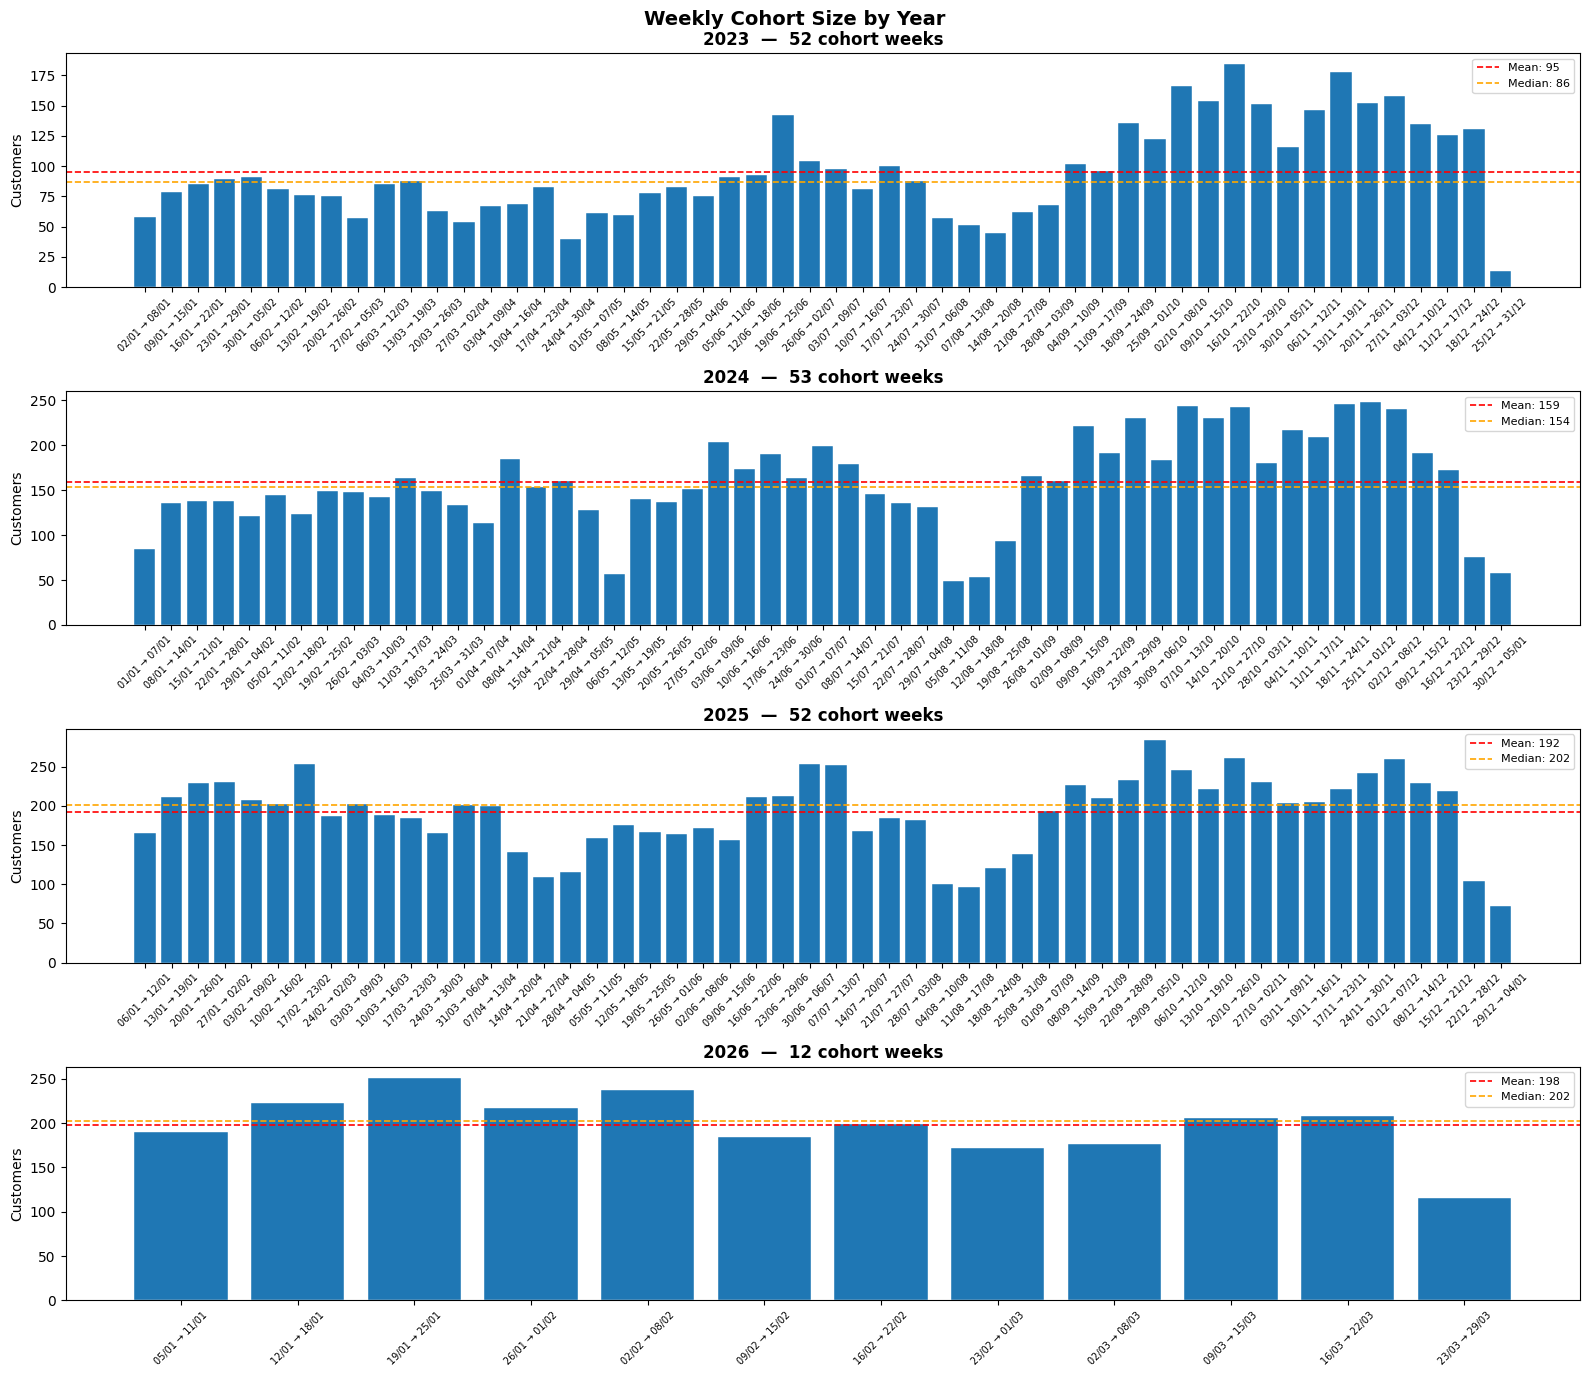

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

cohort['year'] = cohort['cohort_week'].dt.year

years = [2023, 2024, 2025, 2026]
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Weekly Cohort Size by Year', fontsize=14, fontweight='bold')

for ax, year in zip(axes, years):
    data = cohort[cohort['year'] == year]
    ax.bar(data['week_label'], data['total_customers'], edgecolor='white', linewidth=0.3)
    ax.set_title(f'{year}  —  {len(data)} cohort weeks', fontweight='bold')
    ax.set_ylabel('Customers')
    ax.axhline(data['total_customers'].mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {data["total_customers"].mean():.0f}')
    ax.axhline(data['total_customers'].median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data["total_customers"].median():.0f}')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('pipeline_data/cohort_size_bars.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Check the first two 2026 cohort weeks

df = journey
first_two_2026 = cohort[cohort['year'] == 2026].head(2)
print(first_two_2026[['cohort_week', 'week_label', 'total_customers', 'converted']])

# Check decision_days on raw data for those cohorts
mask = df['cohort_week'].isin(first_two_2026['cohort_week'])
print(df[mask][['numero_compte', 'converted', 'first_quote_date', 'decision_days']].head(10))
print(f"\nNull decision_days for converted customers: {df[mask & (df['converted']==1)]['decision_days'].isna().sum()}")

    cohort_week     week_label  total_customers  converted
157  2026-01-05  05/01 → 11/01              190       64.0
158  2026-01-12  12/01 → 18/01              223       57.0
     numero_compte  converted first_quote_date  decision_days
155     CL00002625        0.0       2026-01-05              0
383     CL00063386        1.0       2026-01-15              0
663     CL00066393        0.0       2026-01-05              0
887     CL00068855        0.0       2026-01-15              0
888     CL00068860        1.0       2026-01-07              0
1078    CL00128513        0.0       2026-01-14              0
1091    CL00129108        0.0       2026-01-08              0
1105    CL00129608        1.0       2026-01-13              0
1130    CL00130301        0.0       2026-01-09              0
1152    CL00131185        0.0       2026-01-06              0

Null decision_days for converted customers: 0


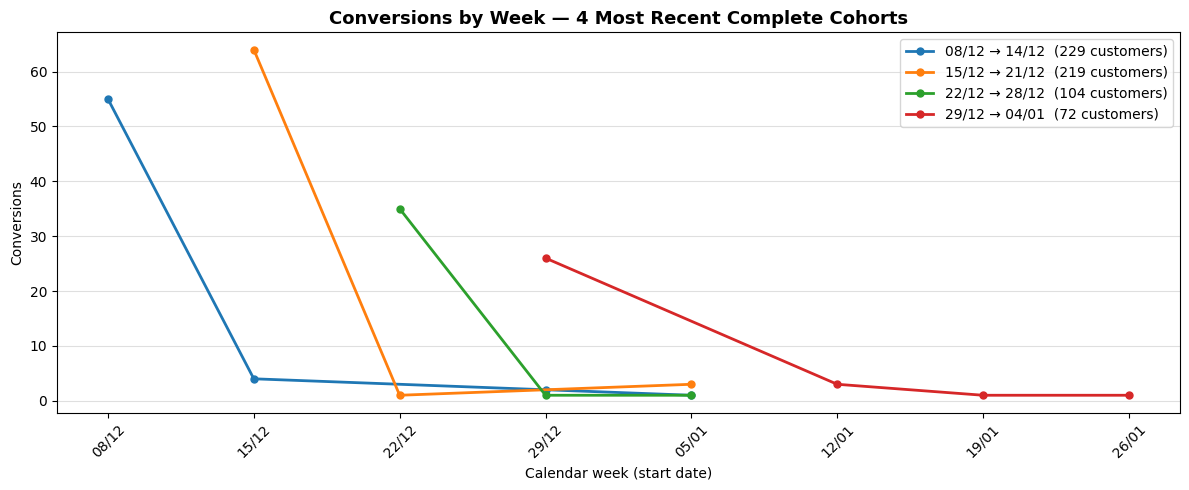

In [5]:
converted_all = df[df['converted'] == 1].copy()
converted_all['conversion_date'] = converted_all['first_quote_date'] + pd.to_timedelta(converted_all['decision_days'], unit='D')
converted_all = converted_all.merge(cohort[['cohort_week']], on='cohort_week')

converted_all['conversion_week'] = (
    (converted_all['conversion_date'].dt.to_period('W').dt.start_time - converted_all['cohort_week'])
    / pd.Timedelta(weeks=1)
).astype(int)

# 4 most recent complete cohorts
recent_4 = cohort[~cohort['cohort_week'].isin(cohort.tail(12)['cohort_week'])].tail(4)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Conversions by Week — 4 Most Recent Complete Cohorts', fontsize=13, fontweight='bold')

for _, row in recent_4.iterrows():
    cohort_start = row['cohort_week']
    label        = row['week_label']
    total        = int(row['total_customers'])

    data   = converted_all[converted_all['cohort_week'] == cohort_start]
    weekly = data.groupby('conversion_week')['numero_compte'].count()
    weekly = weekly[weekly.index <= 4]  # 4-week window

    week_dates = weekly.index.map(lambda w: cohort_start + pd.Timedelta(weeks=w))

    ax.plot(week_dates, weekly.values, marker='o', linewidth=2,
            markersize=5, label=f'{label}  ({total} customers)')

ax.set_xlabel('Calendar week (start date)')
ax.set_ylabel('Conversions')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('pipeline_data/recent_cohorts_4week_window.png', dpi=150, bbox_inches='tight')
plt.show()

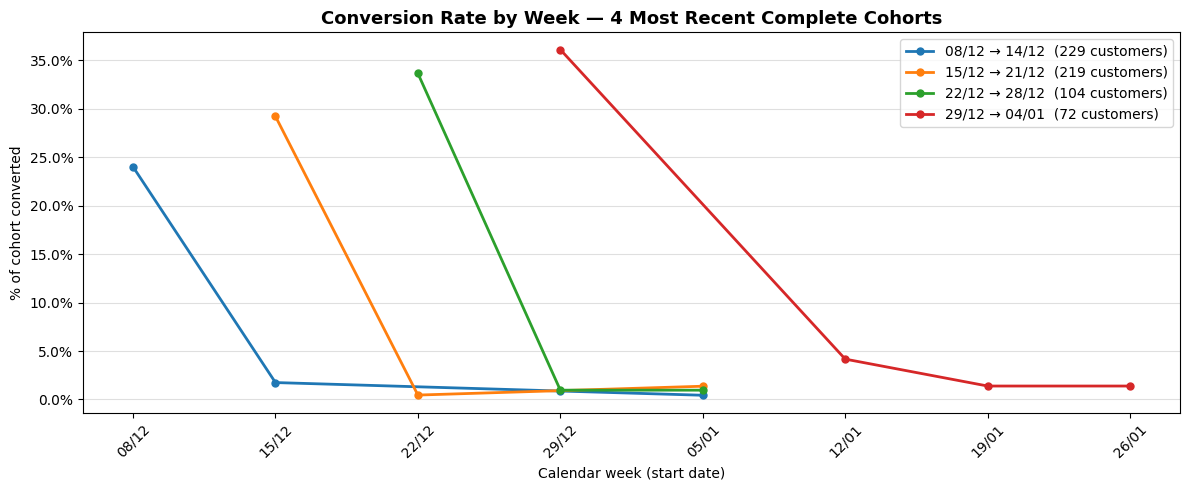

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Conversion Rate by Week — 4 Most Recent Complete Cohorts', fontsize=13, fontweight='bold')

for _, row in recent_4.iterrows():
    cohort_start = row['cohort_week']
    label        = row['week_label']
    total        = int(row['total_customers'])

    data   = converted_all[converted_all['cohort_week'] == cohort_start]
    weekly = data.groupby('conversion_week')['numero_compte'].count()
    weekly = weekly[weekly.index <= 4]  # 4-week window

    weekly_pct = weekly / total * 100   # normalize by cohort size

    week_dates = weekly.index.map(lambda w: cohort_start + pd.Timedelta(weeks=w))

    ax.plot(week_dates, weekly_pct.values, marker='o', linewidth=2,
            markersize=5, label=f'{label}  ({total} customers)')

ax.set_xlabel('Calendar week (start date)')
ax.set_ylabel('% of cohort converted')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('pipeline_data/recent_cohorts_4week_window_pct.png', dpi=150, bbox_inches='tight')
plt.show()